# Assignment 6: Model Evaluation, Explainability, and Fairness Reflection

## University Advising Appointment Non-Completion Prediction

**Course:** MBAI 5310G – AI Programming  
**Model Used:** Decision Tree Classifier  
**Dataset:** `university_advising_completion_dataset.csv`  
**Original outcome column:** `appointment_completed`  
**Business target used for modelling:** `appointment_not_completed`  
**Positive class:** `1 = appointment not completed / intervention risk`

### Business Purpose
The university advising office wants to identify students who may not complete their advising appointments. Early identification can help the advising office send additional reminders, offer flexible appointment modes, or provide targeted follow-up before the appointment date.

This notebook follows all required Assignment 6 tasks:

1. Load and understand the dataset  
2. Define features and target variable  
3. Preprocess data  
4. Train/test split  
5. Train a Decision Tree classification model  
6. Evaluate classification performance  
7. Interpret the confusion matrix  
8. Analyze model errors  
9. Apply cross-validation  
10. Check overfitting and underfitting  
11. Analyze feature importance  
12. Explain the model using SHAP  
13. Explain one prediction using LIME  
14. Reflect on fairness and bias across groups  
15. Provide final business interpretation

## Step 1: Import Required Libraries and Set Up the Project

This step imports the Python libraries needed for data handling, visualization, model training, model evaluation, explainability, and fairness analysis.

The notebook also creates an `outputs/` folder so that charts and result tables are saved automatically. This improves reproducibility because another user can restart the kernel and run all cells from top to bottom.

In [1]:
# Optional dependency check for SHAP and LIME
# If these packages are not installed, this cell will install them.
# If your instructor prefers no installation cells, you may run this once and then comment it out.

import importlib.util
import subprocess
import sys

required_packages = ["shap", "lime"]

for package in required_packages:
    if importlib.util.find_spec(package) is None:
        print(f"Installing {package}...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", package])
    else:
        print(f"{package} is already installed.")

shap is already installed.
lime is already installed.


In [2]:
# Core libraries
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)

# Machine learning libraries
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

# Explainability libraries
import shap
from lime.lime_tabular import LimeTabularExplainer

# Reproducibility
RANDOM_STATE = 42

# Output folder
OUTPUT_DIR = Path("outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

print("Libraries imported successfully.")
print(f"Output folder ready: {OUTPUT_DIR.resolve()}")

Libraries imported successfully.
Output folder ready: C:\Users\praba\OneDrive\Desktop\MFDA\3rd Semester\AI Programming\Assignments\Assignment 6\outputs


## Task 1: Load and Understand the Dataset

In this task, the dataset is loaded and inspected. The inspection includes dataset size, column names, data types, missing values, duplicate records, and target variable distribution.

The original outcome column is `appointment_completed`, where:

- `1` means the appointment was completed
- `0` means the appointment was not completed

For this assignment, the model will focus on intervention risk. Therefore, a new target variable called `appointment_not_completed` is created:

- `1` means the appointment was **not completed**
- `0` means the appointment was **completed**

This makes the positive class directly connected to the business problem: identifying students who may need extra support before the appointment.

In [3]:
# Load the dataset
DATA_PATH = Path("university_advising_completion_dataset.csv")

if not DATA_PATH.exists():
    raise FileNotFoundError(
        f"Dataset not found: {DATA_PATH}. Please keep the dataset in the same folder as this notebook."
    )

advising_df = pd.read_csv(DATA_PATH)

print("Dataset loaded successfully.")
print("Dataset shape:", advising_df.shape)

display(advising_df.head())

Dataset loaded successfully.
Dataset shape: (360, 17)


,appointment_id,student_age,age_group,gender,region,student_level,program_area,appointment_type,booking_lead_days,previous_advising_visits,missed_appointments_last_year,credits_completed,current_gpa,email_reminder_sent,appointment_mode,advisor_rating_previous,appointment_completed
0,UA0001,45,36-50,Male,North,First Year,Health,Course Planning,35,9,0,82,3.64,Yes,Online,2,1
1,UA0002,27,26-35,Female,East,First Year,Science,Career,4,6,0,89,2.94,Yes,In Person,3,1
2,UA0003,33,26-35,Male,West,Second Year,Business,Graduation Check,17,9,1,75,2.02,Yes,In Person,4,1
3,UA0004,41,36-50,Male,East,Third Year,Arts,Career,46,3,0,43,2.23,Yes,In Person,3,1
4,UA0005,40,36-50,Female,North,Second Year,Engineering,Course Planning,10,8,0,39,3.33,No,In Person,5,1


In [4]:
# Dataset size
num_rows, num_cols = advising_df.shape

print(f"Number of rows: {num_rows}")
print(f"Number of columns: {num_cols}")

Number of rows: 360
Number of columns: 17


In [5]:
# Column names
column_names = pd.DataFrame({"Column Names": advising_df.columns})
display(column_names)

,Column Names
0,appointment_id
1,student_age
2,age_group
3,gender
4,region
5,student_level
6,program_area
7,appointment_type
8,booking_lead_days
9,previous_advising_visits


In [6]:
# Data types
data_types_table = pd.DataFrame({
    "Column": advising_df.columns,
    "Data Type": advising_df.dtypes.astype(str).values
})

display(data_types_table)

data_types_table.to_csv(OUTPUT_DIR / "data_types.csv", index=False)

,Column,Data Type
0,appointment_id,str
1,student_age,int64
2,age_group,str
3,gender,str
4,region,str
5,student_level,str
6,program_area,str
7,appointment_type,str
8,booking_lead_days,int64
9,previous_advising_visits,int64


,Column,Missing Values
12,current_gpa,6
0,appointment_id,0
9,previous_advising_visits,0
15,advisor_rating_previous,0
14,appointment_mode,0
13,email_reminder_sent,0
11,credits_completed,0
10,missed_appointments_last_year,0
8,booking_lead_days,0
1,student_age,0


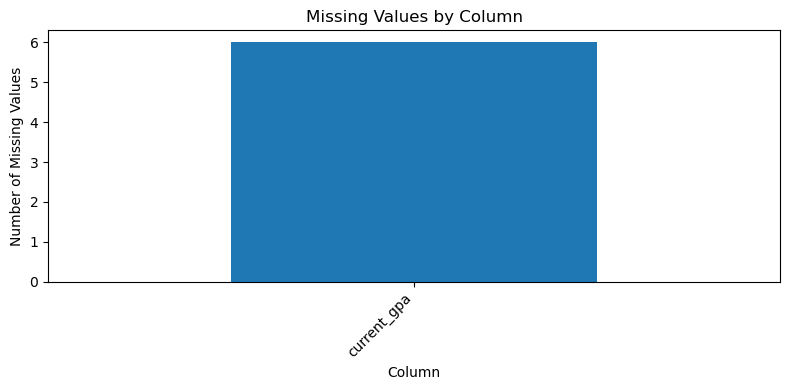

In [7]:
# Missing values by column
missing_values_table = advising_df.isna().sum().reset_index()
missing_values_table.columns = ["Column", "Missing Values"]
missing_values_table = missing_values_table.sort_values("Missing Values", ascending=False)

display(missing_values_table)
missing_values_table.to_csv(OUTPUT_DIR / "missing_values_summary.csv", index=False)

# Missing values chart
missing_nonzero = missing_values_table[missing_values_table["Missing Values"] > 0]

if len(missing_nonzero) > 0:
    ax = missing_nonzero.plot(
        kind="bar",
        x="Column",
        y="Missing Values",
        figsize=(8, 4),
        legend=False
    )
    plt.title("Missing Values by Column")
    plt.xlabel("Column")
    plt.ylabel("Number of Missing Values")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / "missing_values_by_column.png", dpi=300, bbox_inches="tight")
    plt.show()
else:
    print("No missing values found in the dataset.")

In [8]:
# Duplicate records
duplicate_count = advising_df.duplicated().sum()

print(f"Number of duplicate records: {duplicate_count}")

pd.DataFrame({
    "Item": ["Duplicate records"],
    "Count": [duplicate_count]
}).to_csv(OUTPUT_DIR / "duplicate_records_summary.csv", index=False)

Number of duplicate records: 0


,Target Value,Meaning,Count,Percentage
0,0,Completed,233,64.72
1,1,Not Completed,127,35.28


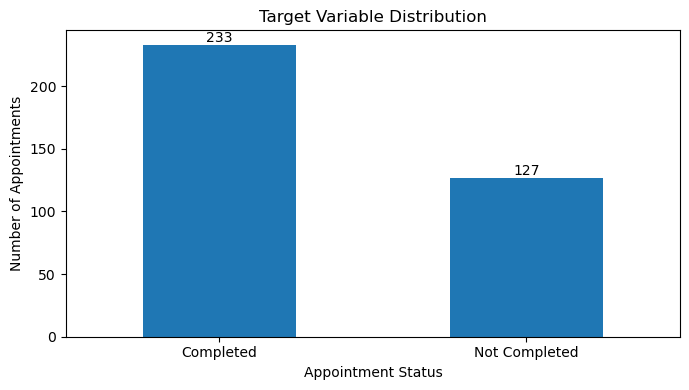

In [9]:
# Create business-focused target variable
# Original: appointment_completed = 1 means completed; 0 means not completed
# New target: appointment_not_completed = 1 means not completed; 0 means completed

advising_df["appointment_not_completed"] = (advising_df["appointment_completed"] == 0).astype(int)

# Target distribution
target_distribution = advising_df["appointment_not_completed"].value_counts().sort_index()
target_distribution_table = pd.DataFrame({
    "Target Value": target_distribution.index,
    "Meaning": ["Completed", "Not Completed"],
    "Count": target_distribution.values,
    "Percentage": (target_distribution.values / len(advising_df) * 100).round(2)
})

display(target_distribution_table)
target_distribution_table.to_csv(OUTPUT_DIR / "target_distribution.csv", index=False)

# Target distribution chart
ax = target_distribution_table.plot(
    kind="bar",
    x="Meaning",
    y="Count",
    figsize=(7, 4),
    legend=False
)
plt.title("Target Variable Distribution")
plt.xlabel("Appointment Status")
plt.ylabel("Number of Appointments")
plt.xticks(rotation=0)

for container in ax.containers:
    ax.bar_label(container)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "target_variable_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

In [10]:
# Short explanation of target balance
completed_count = int(target_distribution.loc[0])
not_completed_count = int(target_distribution.loc[1])
completed_pct = completed_count / len(advising_df) * 100
not_completed_pct = not_completed_count / len(advising_df) * 100

print("Dataset explanation:")
print(f"The dataset contains {num_rows} advising appointment records and {num_cols} original columns.")
print("Each row represents one university advising appointment.")
print("The original outcome column is appointment_completed.")
print("For business interpretation, the modelling target is appointment_not_completed.")
print(f"Completed appointments: {completed_count} ({completed_pct:.2f}%)")
print(f"Not completed appointments: {not_completed_count} ({not_completed_pct:.2f}%)")

if min(completed_pct, not_completed_pct) < 40:
    print("The target variable is moderately imbalanced because one class is clearly larger than the other.")
else:
    print("The target variable is relatively balanced.")

Dataset explanation:
The dataset contains 360 advising appointment records and 17 original columns.
Each row represents one university advising appointment.
The original outcome column is appointment_completed.
For business interpretation, the modelling target is appointment_not_completed.
Completed appointments: 233 (64.72%)
Not completed appointments: 127 (35.28%)
The target variable is moderately imbalanced because one class is clearly larger than the other.


## Task 2: Define Features and Target Variable

This task defines the model input features and the target variable.

### Target Variable
The target variable used for modelling is:

`appointment_not_completed`

This target is created from the original column `appointment_completed` so that the positive class represents the business risk.

### Removed Columns
The following columns are removed from the model input:

- `appointment_id`: identifier only
- `appointment_completed`: original outcome column, removed to avoid target leakage
- `appointment_not_completed`: target variable
- `age_group`, `gender`, `region`: kept only for fairness reflection
- `student_age`: removed because it is closely related to age and could act as an age proxy

### Fairness Columns
The fairness reflection uses:

- `age_group`
- `gender`
- `region`

These columns are not used for model training, but they are used after prediction to compare model performance across groups.

In [11]:
# Define target, identifier, fairness, and proxy columns
TARGET_COL = "appointment_not_completed"
ORIGINAL_TARGET_COL = "appointment_completed"
IDENTIFIER_COLS = ["appointment_id"]
FAIRNESS_COLS = ["age_group", "gender", "region"]
PROXY_COLS = ["student_age"]

# Columns removed from model input
removed_from_model = IDENTIFIER_COLS + [ORIGINAL_TARGET_COL, TARGET_COL] + FAIRNESS_COLS + PROXY_COLS

# Define X and y
X = advising_df.drop(columns=removed_from_model)
y = advising_df[TARGET_COL]

print("Target variable:", TARGET_COL)
print("Positive class: 1 = appointment not completed")
print("Negative class: 0 = appointment completed")
print("\nColumns removed from model input:")
print(removed_from_model)
print("\nModel input features:")
print(X.columns.tolist())
print("\nShape of X:", X.shape)
print("Shape of y:", y.shape)

Target variable: appointment_not_completed
Positive class: 1 = appointment not completed
Negative class: 0 = appointment completed

Columns removed from model input:
['appointment_id', 'appointment_completed', 'appointment_not_completed', 'age_group', 'gender', 'region', 'student_age']

Model input features:
['student_level', 'program_area', 'appointment_type', 'booking_lead_days', 'previous_advising_visits', 'missed_appointments_last_year', 'credits_completed', 'current_gpa', 'email_reminder_sent', 'appointment_mode', 'advisor_rating_previous']

Shape of X: (360, 11)
Shape of y: (360,)


In [12]:
# Identify numerical and categorical features
numerical_features = X.select_dtypes(include=["number"]).columns.tolist()
categorical_features = X.select_dtypes(include=["object", "category"]).columns.tolist()

feature_group_table = pd.DataFrame({
    "Feature Type": ["Numerical", "Categorical"],
    "Number of Features": [len(numerical_features), len(categorical_features)],
    "Columns": [", ".join(numerical_features), ", ".join(categorical_features)]
})

display(feature_group_table)
feature_group_table.to_csv(OUTPUT_DIR / "feature_groups.csv", index=False)

,Feature Type,Number of Features,Columns
0,Numerical,6,"booking_lead_days, previous_advising_visits, m..."
1,Categorical,5,"student_level, program_area, appointment_type,..."


## Task 3: Data Preprocessing

Machine learning models require clean numerical input. This dataset contains both numerical and categorical features, so different preprocessing steps are needed.

### Preprocessing Steps

- Numerical missing values are filled using the median.
- Categorical missing values are filled using the most frequent value.
- Categorical variables are converted into numerical format using one-hot encoding.

The preprocessing steps are placed inside a scikit-learn `Pipeline`. This is important because the preprocessing is fitted only on the training data and then applied to the testing data, which helps avoid data leakage.

In [13]:
# Build a version-compatible OneHotEncoder
# Newer scikit-learn uses sparse_output=False; older versions use sparse=False.
try:
    one_hot_encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
except TypeError:
    one_hot_encoder = OneHotEncoder(handle_unknown="ignore", sparse=False)

# Numerical preprocessing
numerical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median"))
])

# Categorical preprocessing
categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", one_hot_encoder)
])

# Combine preprocessing steps
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numerical_transformer, numerical_features),
        ("cat", categorical_transformer, categorical_features)
    ],
    verbose_feature_names_out=False
)

print("Preprocessing pipeline created successfully.")

Preprocessing pipeline created successfully.


## Task 4: Train/Test Split

The dataset is divided into training and testing data.

- The training data is used to teach the model patterns.
- The testing data is kept separate and used to evaluate how well the model performs on new unseen records.

A stratified split is used to keep the target class distribution similar in both the training and testing sets.

In [14]:
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y
)

split_summary = pd.DataFrame({
    "Dataset": ["X_train", "X_test", "y_train", "y_test"],
    "Shape": [X_train.shape, X_test.shape, y_train.shape, y_test.shape]
})

display(split_summary)
split_summary.to_csv(OUTPUT_DIR / "train_test_split_summary.csv", index=False)

# Check target distribution in train and test sets
split_target_distribution = pd.DataFrame({
    "Training Set": y_train.value_counts().sort_index(),
    "Testing Set": y_test.value_counts().sort_index()
}).rename(index={0: "Completed", 1: "Not Completed"})

display(split_target_distribution)
split_target_distribution.to_csv(OUTPUT_DIR / "target_distribution_train_test.csv")

,Dataset,Shape
0,X_train,"(288, 11)"
1,X_test,"(72, 11)"
2,y_train,"(288,)"
3,y_test,"(72,)"


,Training Set,Testing Set
appointment_not_completed,,
Completed,186,47
Not Completed,102,25


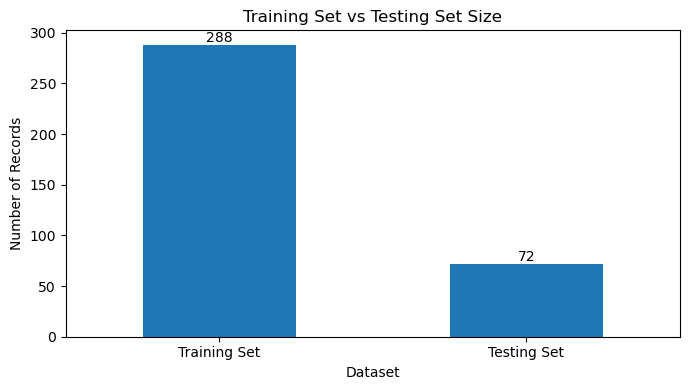

In [15]:
# Visualize training and testing set size
set_sizes = pd.DataFrame({
    "Dataset": ["Training Set", "Testing Set"],
    "Number of Records": [len(X_train), len(X_test)]
})

ax = set_sizes.plot(
    kind="bar",
    x="Dataset",
    y="Number of Records",
    figsize=(7, 4),
    legend=False
)
plt.title("Training Set vs Testing Set Size")
plt.xlabel("Dataset")
plt.ylabel("Number of Records")
plt.xticks(rotation=0)

for container in ax.containers:
    ax.bar_label(container)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "training_testing_set_size.png", dpi=300, bbox_inches="tight")
plt.show()

## Task 5: Train a Classification Model

A simple Decision Tree classification model is trained.

The model is trying to learn patterns that separate completed appointments from appointments that were not completed. For example, it may learn from previous advising visits, missed appointment history, GPA, reminder status, appointment mode, and other advising-related variables.

The final Decision Tree uses controlled depth so that the model remains understandable and does not become too complex.

In [16]:
# Create the Decision Tree model
# max_depth and min_samples_leaf are controlled to keep the model interpretable.
decision_tree_model = DecisionTreeClassifier(
    max_depth=3,
    min_samples_leaf=8,
    random_state=RANDOM_STATE
)

# Combine preprocessing and model into one pipeline
model_pipeline = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("model", decision_tree_model)
])

# Train the model
model_pipeline.fit(X_train, y_train)

# Make predictions on the test data
y_pred = model_pipeline.predict(X_test)
y_pred_proba = model_pipeline.predict_proba(X_test)[:, 1]

print("Decision Tree model trained successfully.")
print("Predictions generated for the testing set.")

Decision Tree model trained successfully.
Predictions generated for the testing set.


In [17]:
# Actual vs predicted comparison table
actual_predicted_table = pd.DataFrame({
    "appointment_id": advising_df.loc[X_test.index, "appointment_id"].values,
    "Actual Value": y_test.values,
    "Predicted Value": y_pred,
    "Actual Meaning": np.where(y_test.values == 1, "Not Completed", "Completed"),
    "Predicted Meaning": np.where(y_pred == 1, "Not Completed", "Completed"),
    "Predicted Probability - Not Completed": y_pred_proba.round(4),
    "Correct Prediction": np.where(y_test.values == y_pred, "Correct", "Incorrect")
})

print("First 12 actual and predicted values:")
display(actual_predicted_table.head(12))

actual_predicted_table.to_csv(OUTPUT_DIR / "actual_vs_predicted_values.csv", index=False)

First 12 actual and predicted values:


,appointment_id,Actual Value,Predicted Value,Actual Meaning,Predicted Meaning,Predicted Probability - Not Completed,Correct Prediction
0,UA0077,0,0,Completed,Completed,0.0777,Correct
1,UA0045,1,1,Not Completed,Not Completed,0.5119,Correct
2,UA0137,1,1,Not Completed,Not Completed,0.5119,Correct
3,UA0263,1,1,Not Completed,Not Completed,0.5119,Correct
4,UA0308,0,0,Completed,Completed,0.0777,Correct
5,UA0283,1,1,Not Completed,Not Completed,0.8846,Correct
6,UA0116,1,1,Not Completed,Not Completed,0.8846,Correct
7,UA0109,0,0,Completed,Completed,0.0777,Correct
8,UA0056,1,1,Not Completed,Not Completed,0.8846,Correct
9,UA0233,1,0,Not Completed,Completed,0.0777,Incorrect


In [18]:
# Count how many of the first few predictions are correct
first_12_correct = (actual_predicted_table.head(12)["Correct Prediction"] == "Correct").sum()

print(f"Among the first 12 test records, {first_12_correct} predictions are correct and {12 - first_12_correct} are incorrect.")
print("This sample comparison helps us see whether the model predictions match the actual appointment outcomes.")

Among the first 12 test records, 11 predictions are correct and 1 are incorrect.
This sample comparison helps us see whether the model predictions match the actual appointment outcomes.


## Task 6: Evaluate the Model

The model is evaluated using four standard classification metrics:

- **Accuracy:** Overall percentage of correct predictions.
- **Precision:** Of the appointments predicted as not completed, how many were actually not completed.
- **Recall:** Of all appointments that were actually not completed, how many the model correctly found.
- **F1-score:** A balanced score that combines precision and recall.

For this business problem, **recall for the not completed class** is especially important because a false negative means the advising office may miss a student who needs extra reminder or support.

In [19]:
# Calculate classification metrics for the positive class: Not Completed = 1
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, pos_label=1)
recall = recall_score(y_test, y_pred, pos_label=1)
f1 = f1_score(y_test, y_pred, pos_label=1)

metrics_table = pd.DataFrame({
    "Metric": ["Accuracy", "Precision for Not Completed", "Recall for Not Completed", "F1-score for Not Completed"],
    "Score": [accuracy, precision, recall, f1],
    "Percentage": [accuracy * 100, precision * 100, recall * 100, f1 * 100]
})

metrics_table["Score"] = metrics_table["Score"].round(4)
metrics_table["Percentage"] = metrics_table["Percentage"].round(2)

display(metrics_table)
metrics_table.to_csv(OUTPUT_DIR / "decision_tree_evaluation_metrics.csv", index=False)

,Metric,Score,Percentage
0,Accuracy,0.6944,69.44
1,Precision for Not Completed,0.5405,54.05
2,Recall for Not Completed,0.8000,80.00
3,F1-score for Not Completed,0.6452,64.52


In [20]:
# Classification report
classification_report_dict = classification_report(
    y_test,
    y_pred,
    target_names=["Completed", "Not Completed"],
    output_dict=True
)

classification_report_table = pd.DataFrame(classification_report_dict).transpose().round(4)
display(classification_report_table)
classification_report_table.to_csv(OUTPUT_DIR / "classification_report.csv")

,precision,recall,f1-score,support
Completed,0.8571,0.6383,0.7317,47.0000
Not Completed,0.5405,0.8000,0.6452,25.0000
accuracy,0.6944,0.6944,0.6944,0.6944
macro avg,0.6988,0.7191,0.6884,72.0000
weighted avg,0.7472,0.6944,0.7017,72.0000


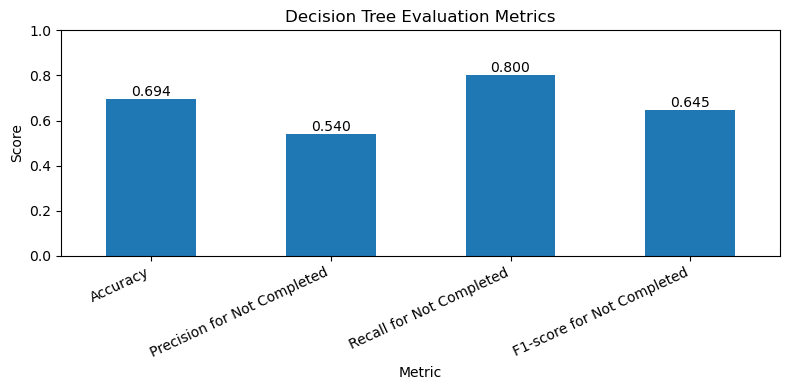

In [21]:
# Evaluation metrics chart
ax = metrics_table.plot(
    kind="bar",
    x="Metric",
    y="Score",
    figsize=(8, 4),
    legend=False
)
plt.title("Decision Tree Evaluation Metrics")
plt.xlabel("Metric")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=25, ha="right")

for container in ax.containers:
    ax.bar_label(container, fmt="%.3f")

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "decision_tree_evaluation_metrics.png", dpi=300, bbox_inches="tight")
plt.show()

## Task 7: Confusion Matrix

The confusion matrix shows the number of correct and incorrect predictions.

For this notebook:

- **True Negative:** Actual completed, predicted completed
- **False Positive:** Actual completed, predicted not completed
- **False Negative:** Actual not completed, predicted completed
- **True Positive:** Actual not completed, predicted not completed

A false negative is especially serious because the advising office may fail to intervene before an appointment is missed. A false positive also matters because staff may spend extra time supporting a student who would have completed the appointment anyway.

In [22]:
# Confusion matrix
cm = confusion_matrix(y_test, y_pred, labels=[0, 1])
tn, fp, fn, tp = cm.ravel()

confusion_matrix_table = pd.DataFrame(
    cm,
    index=["Actual Completed", "Actual Not Completed"],
    columns=["Predicted Completed", "Predicted Not Completed"]
)

display(confusion_matrix_table)
confusion_matrix_table.to_csv(OUTPUT_DIR / "confusion_matrix_values.csv")

business_error_table = pd.DataFrame({
    "Item": ["True Negative", "False Positive", "False Negative", "True Positive"],
    "Value": [tn, fp, fn, tp],
    "Business Meaning": [
        "Completed appointments correctly predicted as completed.",
        "Completed appointments incorrectly predicted as not completed; may cause unnecessary reminders or support.",
        "Not completed appointments incorrectly predicted as completed; may cause missed intervention opportunities.",
        "Not completed appointments correctly identified for possible support."
    ]
})

display(business_error_table)
business_error_table.to_csv(OUTPUT_DIR / "confusion_matrix_business_meaning.csv", index=False)

,Predicted Completed,Predicted Not Completed
Actual Completed,30,17
Actual Not Completed,5,20


,Item,Value,Business Meaning
0,True Negative,30,Completed appointments correctly predicted as ...
1,False Positive,17,Completed appointments incorrectly predicted a...
2,False Negative,5,Not completed appointments incorrectly predict...
3,True Positive,20,Not completed appointments correctly identifie...


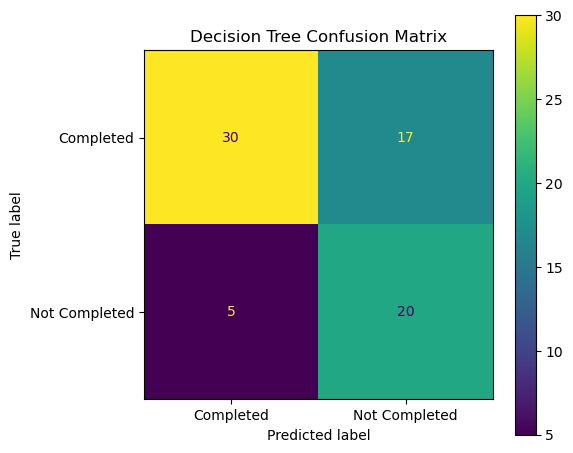

In [23]:
# Confusion matrix visualization
fig, ax = plt.subplots(figsize=(6, 5))
cmd = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Completed", "Not Completed"]
)
cmd.plot(ax=ax, values_format="d")
plt.title("Decision Tree Confusion Matrix")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "decision_tree_confusion_matrix.png", dpi=300, bbox_inches="tight")
plt.show()

In [24]:
print("Business interpretation of errors:")
print(f"False positives: {fp} completed appointments were incorrectly predicted as not completed.")
print(f"False negatives: {fn} not completed appointments were incorrectly predicted as completed.")

if fn > fp:
    print("False negatives are the most common serious error in this model.")
elif fp > fn:
    print("False positives are more common, but false negatives are still more serious for intervention planning.")
else:
    print("False positives and false negatives occurred equally often.")

print("For this business problem, false negatives are more serious because missed at-risk appointments may not receive extra support before the appointment date.")

Business interpretation of errors:
False positives: 17 completed appointments were incorrectly predicted as not completed.
False negatives: 5 not completed appointments were incorrectly predicted as completed.
False positives are more common, but false negatives are still more serious for intervention planning.
For this business problem, false negatives are more serious because missed at-risk appointments may not receive extra support before the appointment date.


## Task 8: Error Analysis

Error analysis goes beyond the confusion matrix by identifying which specific records were predicted correctly or incorrectly.

This task creates:

- A full prediction-status table
- Error type for each prediction
- Count of each error type
- Visualization of error type counts
- A table of wrong predictions only

In [25]:
# Function to identify error type

def assign_error_type(actual, predicted):
    if actual == 0 and predicted == 0:
        return "True Negative"
    if actual == 0 and predicted == 1:
        return "False Positive"
    if actual == 1 and predicted == 0:
        return "False Negative"
    if actual == 1 and predicted == 1:
        return "True Positive"
    return "Unknown"

error_analysis_table = actual_predicted_table.copy()
error_analysis_table["Error Type"] = [
    assign_error_type(actual, predicted)
    for actual, predicted in zip(error_analysis_table["Actual Value"], error_analysis_table["Predicted Value"])
]

# Add selected original variables for easier business interpretation
context_columns = [
    "age_group", "gender", "region", "student_level", "program_area",
    "appointment_type", "missed_appointments_last_year", "previous_advising_visits",
    "current_gpa", "email_reminder_sent", "appointment_mode"
]

error_analysis_table = pd.concat(
    [error_analysis_table.reset_index(drop=True), advising_df.loc[X_test.index, context_columns].reset_index(drop=True)],
    axis=1
)

display(error_analysis_table.head(12))
error_analysis_table.to_csv(OUTPUT_DIR / "error_analysis_all_predictions.csv", index=False)

,appointment_id,Actual Value,Predicted Value,Actual Meaning,Predicted Meaning,Predicted Probability - Not Completed,Correct Prediction,Error Type,age_group,gender,region,student_level,program_area,appointment_type,missed_appointments_last_year,previous_advising_visits,current_gpa,email_reminder_sent,appointment_mode
0,UA0077,0,0,Completed,Completed,0.0777,Correct,True Negative,36-50,Female,North,Graduate,Engineering,Course Planning,0,8,2.85,No,In Person
1,UA0045,1,1,Not Completed,Not Completed,0.5119,Correct,True Positive,18-25,Male,North,First Year,Engineering,Course Planning,0,6,1.70,No,Online
2,UA0137,1,1,Not Completed,Not Completed,0.5119,Correct,True Positive,26-35,Male,North,Fourth Year,Business,Course Planning,0,0,1.62,No,Phone
3,UA0263,1,1,Not Completed,Not Completed,0.5119,Correct,True Positive,26-35,Male,North,Graduate,Business,Course Planning,0,1,2.67,Yes,Online
4,UA0308,0,0,Completed,Completed,0.0777,Correct,True Negative,36-50,Female,West,First Year,Science,Academic Risk,0,11,3.73,Yes,Phone
5,UA0283,1,1,Not Completed,Not Completed,0.8846,Correct,True Positive,36-50,Male,East,Third Year,Health,Academic Risk,2,8,3.41,Yes,Online
6,UA0116,1,1,Not Completed,Not Completed,0.8846,Correct,True Positive,18-25,Male,North,Second Year,Business,Course Planning,3,6,3.36,Yes,Phone
7,UA0109,0,0,Completed,Completed,0.0777,Correct,True Negative,36-50,Male,North,Second Year,Business,Academic Risk,0,12,2.12,No,Phone
8,UA0056,1,1,Not Completed,Not Completed,0.8846,Correct,True Positive,36-50,Male,East,Second Year,Science,Course Planning,2,7,3.15,Yes,In Person
9,UA0233,1,0,Not Completed,Completed,0.0777,Incorrect,False Negative,26-35,Female,South,Graduate,Arts,Academic Risk,0,7,2.70,Yes,In Person


,Error Type,Count
0,True Negative,30
1,True Positive,20
2,False Positive,17
3,False Negative,5


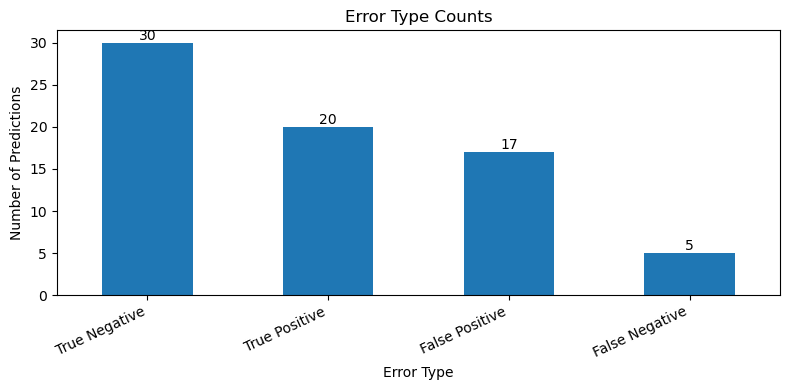

In [26]:
# Count each error type
error_type_counts = error_analysis_table["Error Type"].value_counts().reset_index()
error_type_counts.columns = ["Error Type", "Count"]

display(error_type_counts)
error_type_counts.to_csv(OUTPUT_DIR / "error_type_counts.csv", index=False)

# Error type count visualization
ax = error_type_counts.plot(
    kind="bar",
    x="Error Type",
    y="Count",
    figsize=(8, 4),
    legend=False
)
plt.title("Error Type Counts")
plt.xlabel("Error Type")
plt.ylabel("Number of Predictions")
plt.xticks(rotation=25, ha="right")

for container in ax.containers:
    ax.bar_label(container)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "error_type_counts.png", dpi=300, bbox_inches="tight")
plt.show()

In [27]:
# Table showing wrong predictions only
wrong_predictions_table = error_analysis_table[error_analysis_table["Correct Prediction"] == "Incorrect"].copy()

display(wrong_predictions_table)
wrong_predictions_table.to_csv(OUTPUT_DIR / "wrong_predictions_table.csv", index=False)

most_common_wrong_error = wrong_predictions_table["Error Type"].value_counts().idxmax()
most_common_wrong_count = wrong_predictions_table["Error Type"].value_counts().max()

print(f"Most common wrong prediction type: {most_common_wrong_error} ({most_common_wrong_count} records)")

if most_common_wrong_error == "False Positive":
    print("Business impact: The advising office may spend additional time on students who would have completed the appointment anyway.")
elif most_common_wrong_error == "False Negative":
    print("Business impact: The advising office may miss students who actually need extra support before the appointment.")

,appointment_id,Actual Value,Predicted Value,Actual Meaning,Predicted Meaning,Predicted Probability - Not Completed,Correct Prediction,Error Type,age_group,gender,region,student_level,program_area,appointment_type,missed_appointments_last_year,previous_advising_visits,current_gpa,email_reminder_sent,appointment_mode
9,UA0233,1,0,Not Completed,Completed,0.0777,Incorrect,False Negative,26-35,Female,South,Graduate,Arts,Academic Risk,0,7,2.70,Yes,In Person
16,UA0019,0,1,Completed,Not Completed,0.6667,Incorrect,False Positive,18-25,Female,East,First Year,Arts,Career,2,8,3.20,Yes,Online
18,UA0170,0,1,Completed,Not Completed,0.8846,Incorrect,False Positive,36-50,Male,West,Third Year,Arts,Course Planning,2,4,2.67,Yes,Online
22,UA0318,0,1,Completed,Not Completed,0.5119,Incorrect,False Positive,36-50,Male,East,Third Year,Health,Career,0,1,2.96,No,Online
26,UA0081,0,1,Completed,Not Completed,0.5119,Incorrect,False Positive,18-25,Male,West,Second Year,Engineering,Career,0,6,2.07,Yes,In Person
27,UA0002,0,1,Completed,Not Completed,0.5119,Incorrect,False Positive,26-35,Female,East,First Year,Science,Career,0,6,2.94,Yes,In Person
28,UA0065,1,0,Not Completed,Completed,0.3846,Incorrect,False Negative,26-35,Male,West,Second Year,Engineering,Academic Risk,0,9,2.08,Yes,Online
30,UA0302,0,1,Completed,Not Completed,0.6667,Incorrect,False Positive,26-35,Female,South,First Year,Business,Graduation Check,2,9,3.48,Yes,In Person
33,UA0148,0,1,Completed,Not Completed,0.5119,Incorrect,False Positive,36-50,Male,West,First Year,Arts,Career,1,5,1.92,Yes,Online
34,UA0242,0,1,Completed,Not Completed,0.8846,Incorrect,False Positive,36-50,Male,West,Second Year,Engineering,Career,2,5,2.81,Yes,In Person


Most common wrong prediction type: False Positive (17 records)
Business impact: The advising office may spend additional time on students who would have completed the appointment anyway.


### Additional Error Pattern Interpretation

The error analysis shows that the most common wrong prediction type is **False Positive**. This means the model predicted some appointments as **Not Completed** even though they were actually completed. In a university advising setting, this would usually create extra reminder or follow-up work for staff, but it is less harmful than missing a student who truly needs support.

The model produced fewer **False Negatives**, but this error type remains the more serious business risk. A false negative means the model predicted that a student would complete the appointment, but the appointment was actually not completed. In practice, this could cause the advising office to miss an opportunity to send an additional reminder, offer a flexible appointment mode, or contact the student before the appointment date.

Therefore, the error pattern is acceptable for an early support model because recall for the **Not Completed** class is relatively strong, but staff should still review predictions carefully instead of using the model automatically.


## Task 9: Cross-Validation

Cross-validation evaluates whether the model performs consistently across different splits of the dataset.

This notebook uses 5-fold stratified cross-validation. The dataset is split into five folds. The model trains and evaluates five times, each time using a different fold as the validation set.

If the fold accuracy scores are close to each other, the model performance is more stable. If they vary widely, the model may be sensitive to the data split.

In [28]:
# Cross-validation using the full feature set and target
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

cv_accuracy_scores = cross_val_score(
    model_pipeline,
    X,
    y,
    cv=cv_strategy,
    scoring="accuracy"
)

cv_results_table = pd.DataFrame({
    "Fold": [f"Fold {i}" for i in range(1, len(cv_accuracy_scores) + 1)],
    "Accuracy": cv_accuracy_scores,
    "Accuracy Percentage": cv_accuracy_scores * 100
})

cv_mean_accuracy = cv_accuracy_scores.mean()
cv_std_accuracy = cv_accuracy_scores.std()

display(cv_results_table.round(4))
print(f"Mean cross-validation accuracy: {cv_mean_accuracy:.4f} ({cv_mean_accuracy * 100:.2f}%)")
print(f"Standard deviation: {cv_std_accuracy:.4f} ({cv_std_accuracy * 100:.2f} percentage points)")

cv_results_table.to_csv(OUTPUT_DIR / "cross_validation_results.csv", index=False)

,Fold,Accuracy,Accuracy Percentage
0,Fold 1,0.6250,62.5000
1,Fold 2,0.7222,72.2222
2,Fold 3,0.6111,61.1111
3,Fold 4,0.6944,69.4444
4,Fold 5,0.6806,68.0556


Mean cross-validation accuracy: 0.6667 (66.67%)
Standard deviation: 0.0421 (4.21 percentage points)


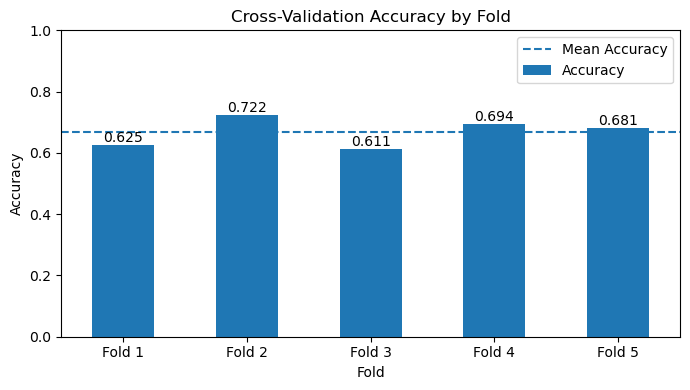

In [29]:
# Cross-validation visualization
ax = cv_results_table.plot(
    kind="bar",
    x="Fold",
    y="Accuracy",
    figsize=(7, 4),
    legend=False
)
plt.axhline(cv_mean_accuracy, linestyle="--", label="Mean Accuracy")
plt.title("Cross-Validation Accuracy by Fold")
plt.xlabel("Fold")
plt.ylabel("Accuracy")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend()

for container in ax.containers:
    ax.bar_label(container, fmt="%.3f")

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "cross_validation_accuracy.png", dpi=300, bbox_inches="tight")
plt.show()

In [30]:
print("Cross-validation interpretation:")
print(f"The mean accuracy is {cv_mean_accuracy * 100:.2f}%.")
print(f"The standard deviation is {cv_std_accuracy * 100:.2f} percentage points.")

if cv_std_accuracy < 0.05:
    print("The accuracy scores are reasonably stable across folds.")
else:
    print("The accuracy scores show noticeable variation across folds, so the model may be sensitive to the data split.")

Cross-validation interpretation:
The mean accuracy is 66.67%.
The standard deviation is 4.21 percentage points.
The accuracy scores are reasonably stable across folds.


## Task 10: Overfitting and Underfitting Analysis

Overfitting happens when a model performs much better on training data than testing data. This means the model may have memorized the training data and may not generalize well.

Underfitting happens when a model performs poorly on both training and testing data. This means the model is too simple to capture useful patterns.

This task compares training and testing accuracy for the final model and also compares model performance across different tree depths.

In [31]:
# Training and testing accuracy for final model
training_accuracy = accuracy_score(y_train, model_pipeline.predict(X_train))
testing_accuracy = accuracy_score(y_test, y_pred)
accuracy_gap = training_accuracy - testing_accuracy

generalization_table = pd.DataFrame({
    "Evaluation Set": ["Training Set", "Testing Set", "Difference"],
    "Accuracy": [training_accuracy, testing_accuracy, accuracy_gap],
    "Percentage": [training_accuracy * 100, testing_accuracy * 100, accuracy_gap * 100]
})

generalization_table["Accuracy"] = generalization_table["Accuracy"].round(4)
generalization_table["Percentage"] = generalization_table["Percentage"].round(2)

display(generalization_table)
generalization_table.to_csv(OUTPUT_DIR / "training_testing_accuracy_summary.csv", index=False)

,Evaluation Set,Accuracy,Percentage
0,Training Set,0.7431,74.31
1,Testing Set,0.6944,69.44
2,Difference,0.0486,4.86


In [32]:
# Compare model performance across different tree depths
depth_results = []

depth_values = list(range(1, 11))

for depth in depth_values:
    depth_model = Pipeline(steps=[
        ("preprocess", preprocessor),
        ("model", DecisionTreeClassifier(
            max_depth=depth,
            min_samples_leaf=8,
            random_state=RANDOM_STATE
        ))
    ])
    
    depth_model.fit(X_train, y_train)
    train_accuracy_depth = accuracy_score(y_train, depth_model.predict(X_train))
    test_accuracy_depth = accuracy_score(y_test, depth_model.predict(X_test))
    
    depth_results.append({
        "Tree Depth": depth,
        "Training Accuracy": train_accuracy_depth,
        "Testing Accuracy": test_accuracy_depth,
        "Accuracy Gap": train_accuracy_depth - test_accuracy_depth
    })

depth_results_table = pd.DataFrame(depth_results)
display(depth_results_table.round(4))
depth_results_table.to_csv(OUTPUT_DIR / "tree_depth_comparison.csv", index=False)

,Tree Depth,Training Accuracy,Testing Accuracy,Accuracy Gap
0,1,0.7292,0.6806,0.0486
1,2,0.7361,0.6806,0.0556
2,3,0.7431,0.6944,0.0486
3,4,0.8090,0.5833,0.2257
4,5,0.8160,0.6389,0.1771
5,6,0.8299,0.6667,0.1632
6,7,0.8368,0.6250,0.2118
7,8,0.8333,0.6944,0.1389
8,9,0.8333,0.6944,0.1389
9,10,0.8333,0.6944,0.1389


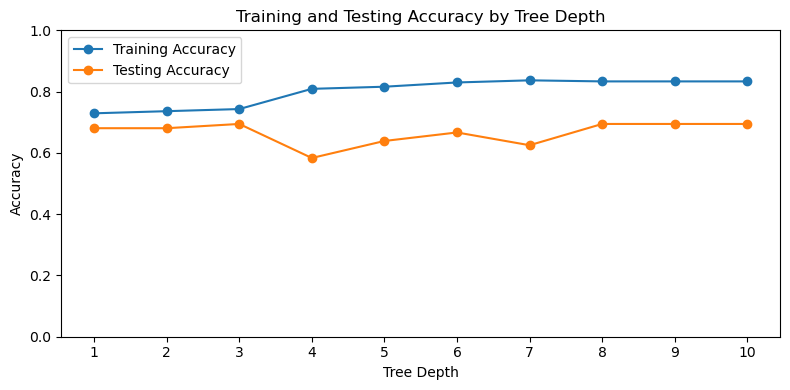

In [33]:
# Visualization of training and testing accuracy by tree depth
ax = depth_results_table.plot(
    x="Tree Depth",
    y=["Training Accuracy", "Testing Accuracy"],
    marker="o",
    figsize=(8, 4)
)
plt.title("Training and Testing Accuracy by Tree Depth")
plt.xlabel("Tree Depth")
plt.ylabel("Accuracy")
plt.ylim(0, 1)
plt.xticks(depth_values)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "training_testing_accuracy_by_depth.png", dpi=300, bbox_inches="tight")
plt.show()

In [34]:
print("Overfitting and underfitting interpretation:")
print(f"Final model training accuracy: {training_accuracy * 100:.2f}%")
print(f"Final model testing accuracy: {testing_accuracy * 100:.2f}%")
print(f"Training-testing accuracy gap: {accuracy_gap * 100:.2f} percentage points")

if accuracy_gap > 0.10:
    print("The model may show signs of overfitting because training accuracy is much higher than testing accuracy.")
elif training_accuracy < 0.60 and testing_accuracy < 0.60:
    print("The model may show signs of underfitting because both training and testing accuracy are low.")
else:
    print("The final model does not show strong overfitting. It appears to be a controlled early-stage model.")

Overfitting and underfitting interpretation:
Final model training accuracy: 74.31%
Final model testing accuracy: 69.44%
Training-testing accuracy gap: 4.86 percentage points
The final model does not show strong overfitting. It appears to be a controlled early-stage model.


## Task 11: Feature Importance

Decision Trees provide feature importance values. These values show which features were most useful for splitting the data inside the tree.

Feature importance can help the advising office understand which variables are most influential in the model. However, feature importance does **not** prove cause and effect. It only shows which features helped the model make predictions.

In [35]:
# Get processed feature names and feature importances
fitted_preprocessor = model_pipeline.named_steps["preprocess"]
fitted_tree = model_pipeline.named_steps["model"]

processed_feature_names = fitted_preprocessor.get_feature_names_out()
feature_importance_values = fitted_tree.feature_importances_

feature_importance_table = pd.DataFrame({
    "Feature": processed_feature_names,
    "Importance": feature_importance_values,
    "Importance Percentage": feature_importance_values * 100
}).sort_values("Importance", ascending=False)

feature_importance_table["Importance"] = feature_importance_table["Importance"].round(6)
feature_importance_table["Importance Percentage"] = feature_importance_table["Importance Percentage"].round(2)

display(feature_importance_table.head(15))
feature_importance_table.to_csv(OUTPUT_DIR / "decision_tree_feature_importance.csv", index=False)

,Feature,Importance,Importance Percentage
2,missed_appointments_last_year,0.445181,44.52
1,previous_advising_visits,0.243925,24.39
4,current_gpa,0.189158,18.92
5,advisor_rating_previous,0.096745,9.67
6,student_level_First Year,0.024991,2.50
0,booking_lead_days,0.000000,0.00
15,program_area_Science,0.000000,0.00
23,appointment_mode_Online,0.000000,0.00
22,appointment_mode_In Person,0.000000,0.00
21,email_reminder_sent_Yes,0.000000,0.00


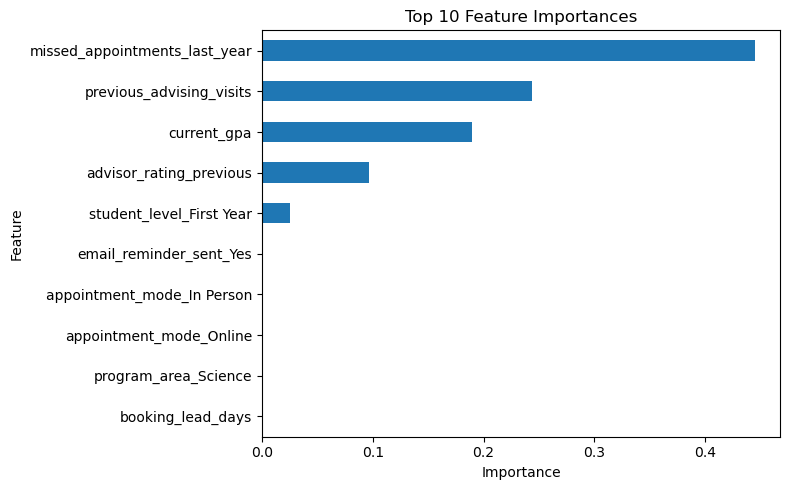

In [36]:
# Top feature importance visualization
top_features = feature_importance_table.head(10).sort_values("Importance")

ax = top_features.plot(
    kind="barh",
    x="Feature",
    y="Importance",
    figsize=(8, 5),
    legend=False
)
plt.title("Top 10 Feature Importances")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "top_10_feature_importance.png", dpi=300, bbox_inches="tight")
plt.show()

In [37]:
print("Business meaning of the most important features:")

for _, row in feature_importance_table.head(5).iterrows():
    feature = row["Feature"]
    importance_pct = row["Importance Percentage"]
    print(f"- {feature}: {importance_pct:.2f}% importance")

print("\nImportant reminder:")
print("Feature importance does not prove that a feature causes appointment non-completion.")
print("It only shows which features were useful for this Decision Tree model's prediction splits.")

Business meaning of the most important features:
- missed_appointments_last_year: 44.52% importance
- previous_advising_visits: 24.39% importance
- current_gpa: 18.92% importance
- advisor_rating_previous: 9.67% importance
- student_level_First Year: 2.50% importance

Important reminder:
Feature importance does not prove that a feature causes appointment non-completion.
It only shows which features were useful for this Decision Tree model's prediction splits.


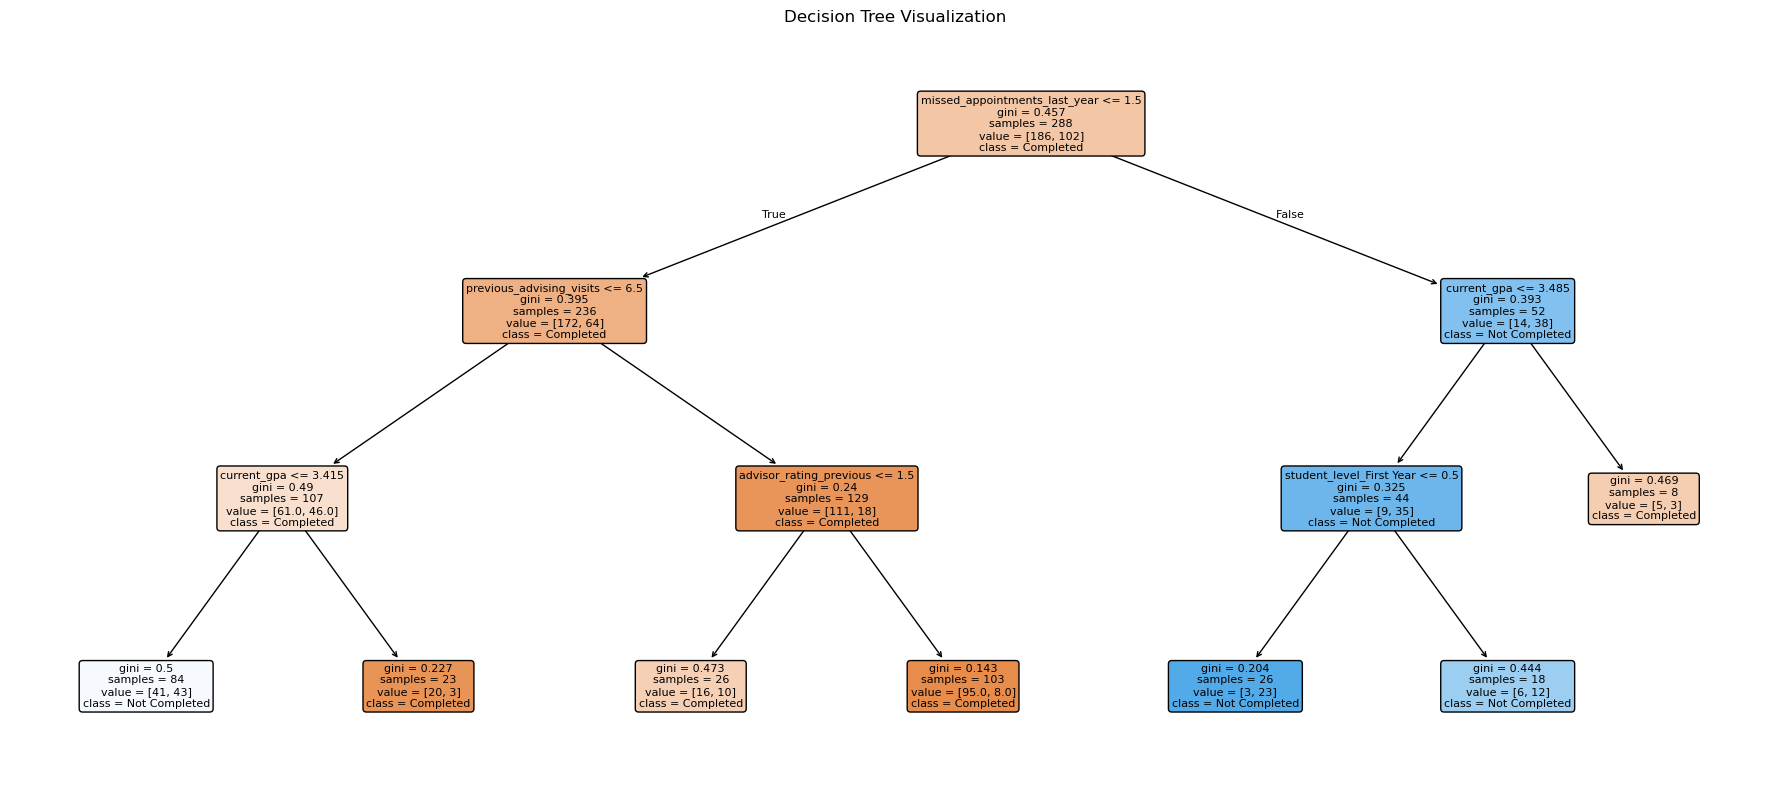

In [38]:
# Optional: Visualize the final Decision Tree
plt.figure(figsize=(18, 8))
plot_tree(
    fitted_tree,
    feature_names=processed_feature_names,
    class_names=["Completed", "Not Completed"],
    filled=True,
    rounded=True,
    fontsize=8
)
plt.title("Decision Tree Visualization")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "decision_tree_visualization.png", dpi=300, bbox_inches="tight")
plt.show()

## Task 12: SHAP Explanation

SHAP helps explain how features influence model predictions.

Basic feature importance shows which features are important overall, but SHAP goes further by showing how features push predictions toward or away from the positive class.

In this notebook, the positive class is:

`1 = appointment not completed`

A positive SHAP value pushes the prediction toward **Not Completed**. A negative SHAP value pushes the prediction toward **Completed**.

In [39]:
# Prepare transformed data for SHAP
X_train_processed = fitted_preprocessor.transform(X_train)
X_test_processed = fitted_preprocessor.transform(X_test)

X_train_processed_df = pd.DataFrame(X_train_processed, columns=processed_feature_names, index=X_train.index)
X_test_processed_df = pd.DataFrame(X_test_processed, columns=processed_feature_names, index=X_test.index)

print("Processed training data shape:", X_train_processed_df.shape)
print("Processed testing data shape:", X_test_processed_df.shape)

Processed training data shape: (288, 25)
Processed testing data shape: (72, 25)


In [40]:
# SHAP explanation for the Decision Tree model
shap_explainer = shap.TreeExplainer(fitted_tree)
raw_shap_values = shap_explainer.shap_values(X_test_processed_df)

# SHAP output format can differ by version.
# This block extracts SHAP values for the positive class: Not Completed = 1.
if isinstance(raw_shap_values, list):
    shap_values_positive = raw_shap_values[1]
    expected_value_positive = shap_explainer.expected_value[1]
elif hasattr(raw_shap_values, "ndim") and raw_shap_values.ndim == 3:
    shap_values_positive = raw_shap_values[:, :, 1]
    expected_value_positive = shap_explainer.expected_value[1]
else:
    shap_values_positive = raw_shap_values
    expected_value_positive = shap_explainer.expected_value

print("SHAP values prepared for the positive class: Not Completed.")
print("SHAP values shape:", np.array(shap_values_positive).shape)

SHAP values prepared for the positive class: Not Completed.
SHAP values shape: (72, 25)


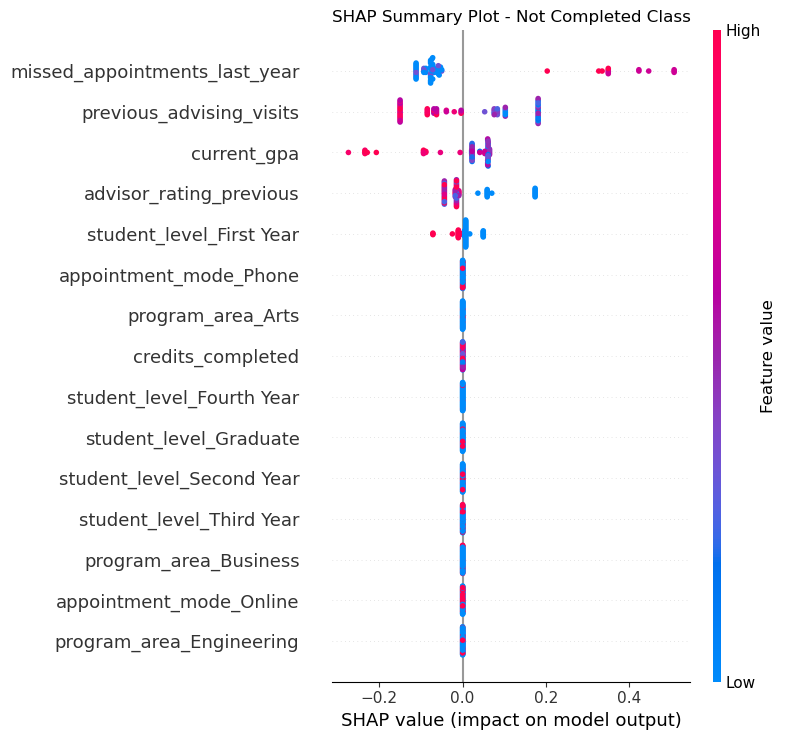

In [41]:
# SHAP summary plot
plt.figure()
shap.summary_plot(
    shap_values_positive,
    X_test_processed_df,
    max_display=15,
    show=False
)
plt.title("SHAP Summary Plot - Not Completed Class")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "shap_summary_plot.png", dpi=300, bbox_inches="tight")
plt.show()

### SHAP Summary Plot Interpretation

The SHAP summary plot explains the global behaviour of the Decision Tree model for the positive class, **Not Completed**. In this notebook, positive SHAP values push a prediction toward **appointment not completed**, while negative SHAP values push a prediction toward **appointment completed**.

The global SHAP pattern is consistent with the Decision Tree feature importance results. The feature `missed_appointments_last_year` is the strongest global signal. Higher values of this feature push predictions toward **Not Completed**, which means students with more previous missed appointments are treated by the model as higher intervention-risk cases. This is also business-sensible because past missed appointments may indicate scheduling difficulty, lower engagement, or a need for additional reminders.

The feature `previous_advising_visits` is also important. In the tree, lower or moderate advising-visit history tends to push some records toward **Not Completed**, while higher advising engagement tends to reduce non-completion risk. From a business perspective, this suggests that students who have stronger previous contact with advising may be more familiar with the advising process and may be more likely to attend.

The feature `current_gpa` also affects the prediction direction. Lower GPA values generally push predictions toward **Not Completed**, while higher GPA values tend to push predictions toward **Completed**. This does not mean GPA causes appointment completion, but it suggests that GPA may be acting as a signal for students who need additional academic support.

The feature `advisor_rating_previous` provides another service-quality signal. Lower previous advisor ratings may increase non-completion risk, while stronger ratings may support completion. This should be interpreted carefully because feature importance and SHAP values explain model behaviour; they do not prove cause and effect.


In [42]:
# Select one individual record for local SHAP explanation
# Prefer a record predicted as Not Completed. If none exists, use the first test record.
positive_prediction_positions = np.where(y_pred == 1)[0]

if len(positive_prediction_positions) > 0:
    selected_position = int(positive_prediction_positions[0])
else:
    selected_position = 0

selected_index = X_test.index[selected_position]
selected_record_original = X_test.iloc[[selected_position]]
selected_actual = int(y_test.iloc[selected_position])
selected_prediction = int(y_pred[selected_position])
selected_probability = float(y_pred_proba[selected_position])

print("Selected test record position:", selected_position)
print("Selected original dataset index:", selected_index)
print("Actual:", "Not Completed" if selected_actual == 1 else "Completed")
print("Predicted:", "Not Completed" if selected_prediction == 1 else "Completed")
print(f"Predicted probability of Not Completed: {selected_probability:.4f}")

display(selected_record_original)

Selected test record position: 1
Selected original dataset index: 44
Actual: Not Completed
Predicted: Not Completed
Predicted probability of Not Completed: 0.5119


,student_level,program_area,appointment_type,booking_lead_days,previous_advising_visits,missed_appointments_last_year,credits_completed,current_gpa,email_reminder_sent,appointment_mode,advisor_rating_previous
44,First Year,Engineering,Course Planning,32,6,0,117,1.7,No,Online,2


In [43]:
# SHAP explanation table for the selected individual record
local_shap_table = pd.DataFrame({
    "Feature": processed_feature_names,
    "Feature Value": X_test_processed_df.iloc[selected_position].values,
    "SHAP Value for Not Completed": shap_values_positive[selected_position]
})

local_shap_table["Absolute SHAP Value"] = local_shap_table["SHAP Value for Not Completed"].abs()
local_shap_table = local_shap_table.sort_values("Absolute SHAP Value", ascending=False)

display(local_shap_table.head(10))
local_shap_table.to_csv(OUTPUT_DIR / "shap_individual_record_explanation.csv", index=False)

,Feature,Feature Value,SHAP Value for Not Completed,Absolute SHAP Value
1,previous_advising_visits,6.0,0.181343,0.181343
4,current_gpa,1.7,0.060126,0.060126
2,missed_appointments_last_year,0.0,-0.058424,0.058424
5,advisor_rating_previous,2.0,-0.014873,0.014873
6,student_level_First Year,1.0,-0.010434,0.010434
0,booking_lead_days,32.0,0.000000,0.000000
15,program_area_Science,0.0,0.000000,0.000000
23,appointment_mode_Online,1.0,0.000000,0.000000
22,appointment_mode_In Person,0.0,0.000000,0.000000
21,email_reminder_sent_Yes,0.0,0.000000,0.000000


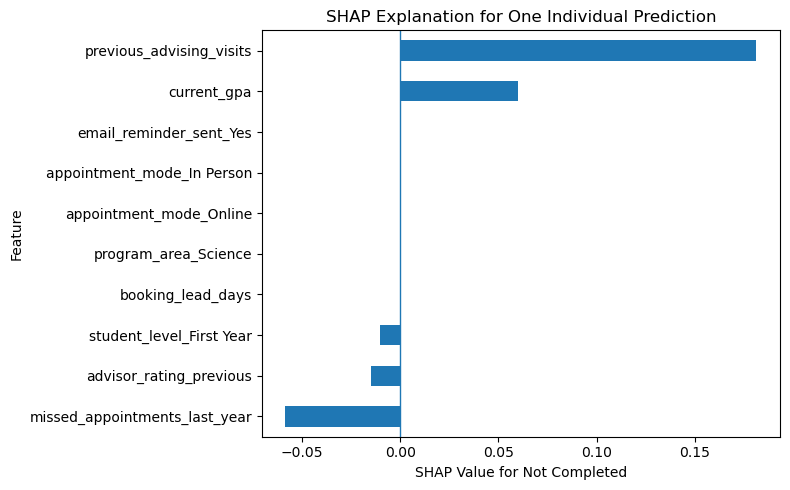

Interpretation:
Positive SHAP values push the prediction toward Not Completed.
Negative SHAP values push the prediction toward Completed.


In [44]:
# Local SHAP bar chart for selected record
top_local_shap = local_shap_table.head(10).sort_values("SHAP Value for Not Completed")

ax = top_local_shap.plot(
    kind="barh",
    x="Feature",
    y="SHAP Value for Not Completed",
    figsize=(8, 5),
    legend=False
)
plt.axvline(0, linewidth=1)
plt.title("SHAP Explanation for One Individual Prediction")
plt.xlabel("SHAP Value for Not Completed")
plt.ylabel("Feature")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "shap_individual_prediction.png", dpi=300, bbox_inches="tight")
plt.show()

print("Interpretation:")
print("Positive SHAP values push the prediction toward Not Completed.")
print("Negative SHAP values push the prediction toward Completed.")

### SHAP Individual Prediction Interpretation

For the selected individual record, the model predicted **Not Completed** with a probability close to the decision boundary. The SHAP table shows which features pushed this specific prediction toward or away from the **Not Completed** class.

The strongest local SHAP contributor was `previous_advising_visits = 6`, which pushed the prediction toward **Not Completed**. The student's `current_gpa = 1.70` also pushed the prediction toward **Not Completed**, suggesting that this record looks like a student who may need additional academic or advising support.

However, `missed_appointments_last_year = 0` pushed the prediction away from **Not Completed** and toward **Completed**. This is important because the student does not have a recent missed-appointment history, which reduces the model's concern for this record. The final prediction is therefore based on a balance of risk-increasing and risk-reducing signals rather than one feature alone.

This individual SHAP explanation is useful because it shows why one specific student appointment received its prediction. It helps advising staff understand the model output before deciding whether a reminder, flexible appointment option, or follow-up support is appropriate.


## Task 13: LIME Explanation

LIME explains one individual prediction by creating a simple local explanation around that record.

For business users, LIME is useful because it shows which features support a prediction and which features work against it for one specific student appointment.

In this notebook, LIME explains the same selected record used in the SHAP individual explanation.

In [45]:
# LIME works best with numerical arrays.
# We use the processed feature matrix so that all variables are numeric after imputation and encoding.

lime_explainer = LimeTabularExplainer(
    training_data=X_train_processed_df.values,
    feature_names=processed_feature_names.tolist(),
    class_names=["Completed", "Not Completed"],
    mode="classification",
    discretize_continuous=True,
    random_state=RANDOM_STATE
)

lime_exp = lime_explainer.explain_instance(
    data_row=X_test_processed_df.iloc[selected_position].values,
    predict_fn=fitted_tree.predict_proba,
    num_features=10,
    labels=[1]
)

selected_probability_table = pd.DataFrame({
    "Class": ["Completed", "Not Completed"],
    "Predicted Probability": model_pipeline.predict_proba(selected_record_original)[0]
})

print("Prediction probabilities for selected record:")
display(selected_probability_table)
selected_probability_table.to_csv(OUTPUT_DIR / "lime_selected_record_prediction_probability.csv", index=False)

Prediction probabilities for selected record:


,Class,Predicted Probability
0,Completed,0.488095
1,Not Completed,0.511905


In [46]:
# LIME explanation table for the positive class
lime_explanation_table = pd.DataFrame(
    lime_exp.as_list(label=1),
    columns=["Feature Condition", "Contribution to Not Completed Prediction"]
)

display(lime_explanation_table)
lime_explanation_table.to_csv(OUTPUT_DIR / "lime_explanation_table.csv", index=False)

,Feature Condition,Contribution to Not Completed Prediction
0,missed_appointments_last_year <= 0.00,-0.215532
1,3.00 < previous_advising_visits <= 7.00,0.118254
2,current_gpa <= 2.17,0.097072
3,advisor_rating_previous <= 2.00,0.063448
4,student_level_First Year > 0.00,-0.035184
5,student_level_Fourth Year <= 0.00,0.019260
6,credits_completed > 92.00,0.017948
7,appointment_type_Graduation Check <= 0.00,-0.015528
8,appointment_mode_Phone <= 0.00,0.013901
9,email_reminder_sent_No > 0.00,-0.012217


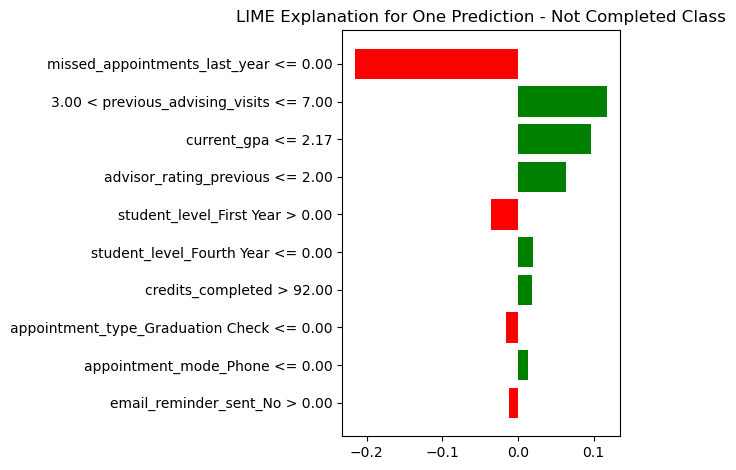

LIME interpretation:
Positive contribution values support the Not Completed prediction.
Negative contribution values work against the Not Completed prediction and support Completed instead.


In [47]:
# LIME visualization
fig = lime_exp.as_pyplot_figure(label=1)
plt.title("LIME Explanation for One Prediction - Not Completed Class")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "lime_individual_prediction.png", dpi=300, bbox_inches="tight")
plt.show()

print("LIME interpretation:")
print("Positive contribution values support the Not Completed prediction.")
print("Negative contribution values work against the Not Completed prediction and support Completed instead.")

### LIME Individual Prediction Walkthrough

For the selected test record, the model predicted a probability of approximately **51.19% for Not Completed** and **48.81% for Completed**. This means the prediction is close to the classification boundary, so the record should be interpreted carefully rather than treated as a highly confident prediction.

The LIME explanation shows the local feature conditions that influenced this one prediction. The condition `3.00 < previous_advising_visits <= 7.00` contributed positively toward **Not Completed**, suggesting that this level of previous advising activity was treated as a local risk signal for this record. The condition `current_gpa <= 2.17` also supported the **Not Completed** prediction, which is consistent with the idea that students with lower GPA may need more advising support. The condition `advisor_rating_previous <= 2.00` also contributed positively toward **Not Completed**, suggesting that a weaker prior advising experience may be related to appointment non-completion risk in this local explanation.

Some conditions worked against the **Not Completed** prediction. For example, `missed_appointments_last_year <= 0.00` had a negative contribution, meaning it supported **Completed** rather than **Not Completed**. This makes business sense because a student with no recent missed appointments may be more likely to attend. The condition `email_reminder_sent_No > 0.00` also worked slightly against the **Not Completed** prediction in this local explanation, although this should not be interpreted as a causal finding.

LIME is helpful for business users because it translates one model prediction into understandable feature conditions. Instead of only saying that the model predicted **Not Completed**, LIME shows which specific conditions supported that decision and which conditions opposed it.


## Task 14: Fairness and Bias Reflection

Fairness analysis compares model behaviour across different groups.

The fairness columns are **not used as model inputs**, but they are used after prediction to understand whether the model performs similarly across groups.

This notebook analyzes three group-related columns:

- `age_group`
- `gender`
- `region`

For each group, the analysis reports:

- Number of records in each group
- Actual positive rate
- Predicted positive rate
- Accuracy by group

The positive class is `Not Completed`.

In [48]:
# Create a fairness analysis dataset using the test set only
fairness_test_df = advising_df.loc[X_test.index, FAIRNESS_COLS].copy()
fairness_test_df["Actual_Not_Completed"] = y_test.values
fairness_test_df["Predicted_Not_Completed"] = y_pred
fairness_test_df["Correct"] = (fairness_test_df["Actual_Not_Completed"] == fairness_test_df["Predicted_Not_Completed"]).astype(int)

# Function to summarize performance by group

def fairness_summary_by_group(data, group_col):
    summary = data.groupby(group_col).agg(
        Number_of_Records=("Actual_Not_Completed", "size"),
        Actual_Positive_Rate=("Actual_Not_Completed", "mean"),
        Predicted_Positive_Rate=("Predicted_Not_Completed", "mean"),
        Accuracy_By_Group=("Correct", "mean")
    ).reset_index()
    
    summary["Actual_Positive_Rate_Percentage"] = (summary["Actual_Positive_Rate"] * 100).round(2)
    summary["Predicted_Positive_Rate_Percentage"] = (summary["Predicted_Positive_Rate"] * 100).round(2)
    summary["Accuracy_By_Group_Percentage"] = (summary["Accuracy_By_Group"] * 100).round(2)
    
    return summary

fairness_results = {}

for group_col in FAIRNESS_COLS:
    summary = fairness_summary_by_group(fairness_test_df, group_col)
    fairness_results[group_col] = summary
    print(f"Fairness summary by {group_col}:")
    display(summary)
    summary.to_csv(OUTPUT_DIR / f"fairness_summary_by_{group_col}.csv", index=False)

Fairness summary by age_group:


,age_group,Number_of_Records,Actual_Positive_Rate,Predicted_Positive_Rate,Accuracy_By_Group,Actual_Positive_Rate_Percentage,Predicted_Positive_Rate_Percentage,Accuracy_By_Group_Percentage
0,18-25,23,0.391304,0.478261,0.826087,39.13,47.83,82.61
1,26-35,19,0.315789,0.526316,0.578947,31.58,52.63,57.89
2,36-50,30,0.333333,0.533333,0.666667,33.33,53.33,66.67


Fairness summary by gender:


,gender,Number_of_Records,Actual_Positive_Rate,Predicted_Positive_Rate,Accuracy_By_Group,Actual_Positive_Rate_Percentage,Predicted_Positive_Rate_Percentage,Accuracy_By_Group_Percentage
0,Female,29,0.275862,0.448276,0.551724,27.59,44.83,55.17
1,Male,43,0.395349,0.558140,0.790698,39.53,55.81,79.07


Fairness summary by region:


,region,Number_of_Records,Actual_Positive_Rate,Predicted_Positive_Rate,Accuracy_By_Group,Actual_Positive_Rate_Percentage,Predicted_Positive_Rate_Percentage,Accuracy_By_Group_Percentage
0,East,15,0.400000,0.666667,0.600000,40.00,66.67,60.00
1,North,20,0.400000,0.450000,0.850000,40.00,45.00,85.00
2,South,16,0.250000,0.375000,0.750000,25.00,37.50,75.00
3,West,21,0.333333,0.571429,0.571429,33.33,57.14,57.14


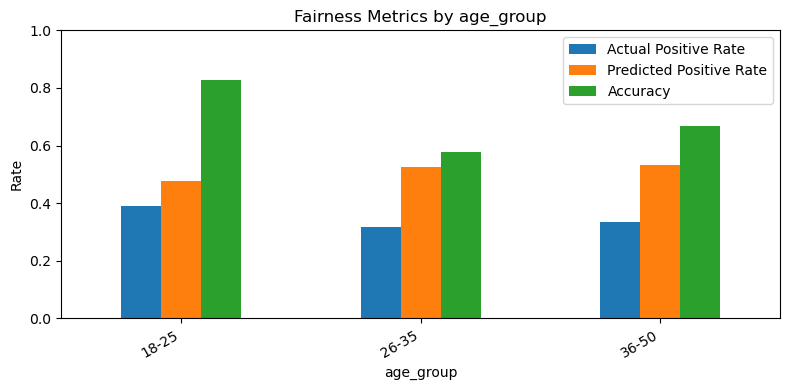

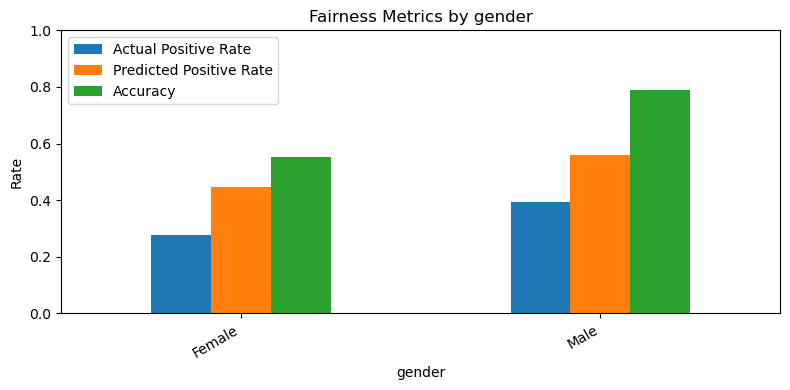

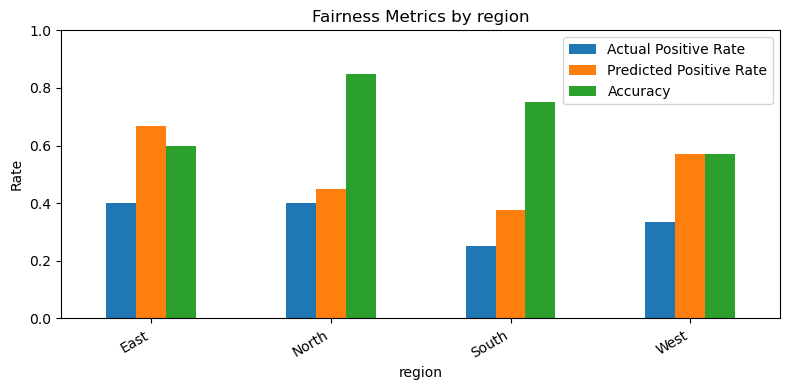

In [49]:
# Visualize fairness metrics for each group column
for group_col, summary in fairness_results.items():
    plot_data = summary[[
        group_col,
        "Actual_Positive_Rate",
        "Predicted_Positive_Rate",
        "Accuracy_By_Group"
    ]].set_index(group_col)
    
    ax = plot_data.plot(kind="bar", figsize=(8, 4))
    plt.title(f"Fairness Metrics by {group_col}")
    plt.xlabel(group_col)
    plt.ylabel("Rate")
    plt.ylim(0, 1)
    plt.xticks(rotation=30, ha="right")
    plt.legend(["Actual Positive Rate", "Predicted Positive Rate", "Accuracy"])
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / f"fairness_metrics_by_{group_col}.png", dpi=300, bbox_inches="tight")
    plt.show()

In [50]:
# Fairness reflection text based on the calculated tables
print("Fairness and bias reflection:")

for group_col, summary in fairness_results.items():
    max_accuracy = summary["Accuracy_By_Group"].max()
    min_accuracy = summary["Accuracy_By_Group"].min()
    accuracy_gap_group = max_accuracy - min_accuracy
    
    max_pred_rate = summary["Predicted_Positive_Rate"].max()
    min_pred_rate = summary["Predicted_Positive_Rate"].min()
    predicted_rate_gap = max_pred_rate - min_pred_rate
    
    print(f"\nGroup column: {group_col}")
    print(f"Accuracy gap between highest and lowest group: {accuracy_gap_group * 100:.2f} percentage points")
    print(f"Predicted positive rate gap between highest and lowest group: {predicted_rate_gap * 100:.2f} percentage points")
    
    if accuracy_gap_group > 0.15 or predicted_rate_gap > 0.20:
        print("This suggests a possible fairness concern that should be investigated before real business use.")
    else:
        print("This does not show a large fairness gap by this simple test, but ongoing monitoring is still needed.")

print("\nImportant note:")
print("This fairness analysis is an initial reflection only. It does not prove the model is fully fair or unfair.")
print("In real use, the university should continue monitoring fairness with larger datasets and human review.")

Fairness and bias reflection:

Group column: age_group
Accuracy gap between highest and lowest group: 24.71 percentage points
Predicted positive rate gap between highest and lowest group: 5.51 percentage points
This suggests a possible fairness concern that should be investigated before real business use.

Group column: gender
Accuracy gap between highest and lowest group: 23.90 percentage points
Predicted positive rate gap between highest and lowest group: 10.99 percentage points
This suggests a possible fairness concern that should be investigated before real business use.

Group column: region
Accuracy gap between highest and lowest group: 27.86 percentage points
Predicted positive rate gap between highest and lowest group: 29.17 percentage points
This suggests a possible fairness concern that should be investigated before real business use.

Important note:
This fairness analysis is an initial reflection only. It does not prove the model is fully fair or unfair.
In real use, the un

### Human Fairness and Bias Reflection

The fairness analysis compares model behaviour across `age_group`, `gender`, and `region`. These columns were not used as model inputs, but they were reviewed after prediction to understand whether the model behaves differently across groups.

For `age_group`, the model accuracy is highest for the **18-25** group at **82.61%** and lowest for the **26-35** group at **57.89%**. The predicted positive rate is also higher than the actual positive rate for every age group. This means the model tends to flag more students as at risk of appointment non-completion than actually failed to complete appointments. From an equity perspective, the lower accuracy for the 26-35 group should be reviewed because this group may include students with different work, family, or scheduling responsibilities.

For `gender`, the model accuracy is **79.07%** for male students and **55.17%** for female students. The predicted positive rate is also higher for both groups than the actual positive rate. This gap does not automatically prove discrimination, especially because the test set is relatively small, but it is a fairness concern that should be investigated before real deployment. The university should avoid relying on the model in a way that causes one group to receive unnecessary follow-up or another group to receive less accurate support.

For `region`, the model accuracy ranges from **85.00%** for the North region to **57.14%** for the West region. The East region has a predicted positive rate of **66.67%**, while its actual positive rate is **40.00%**, suggesting that the model may over-identify East-region students as at risk. The West region also has relatively low accuracy. These differences may reflect access, transportation, online connectivity, campus distance, or other contextual factors that are not fully captured by the dataset.

Overall, the fairness results show that the model is useful as an early prototype, but it is not ready for fully automated advising decisions. The model should support human review, not replace it. Before real use, the university should test the model on a larger dataset, monitor accuracy and predicted-risk rates by group, investigate why some groups have lower accuracy, and make sure interventions are helpful rather than punitive.


## Task 15: Final Business Interpretation

This final section summarizes the model from a business perspective.

The goal is not only to report accuracy, but also to explain whether the model is reliable, explainable, and fair enough for decision-making.

In [51]:
# Prepare final interpretation values
main_metric_name = "Recall for Not Completed"
main_metric_value = recall
main_error_type = most_common_wrong_error
important_feature_1 = feature_importance_table.iloc[0]["Feature"]
important_feature_2 = feature_importance_table.iloc[1]["Feature"] if len(feature_importance_table) > 1 else "N/A"
important_feature_3 = feature_importance_table.iloc[2]["Feature"] if len(feature_importance_table) > 2 else "N/A"

# Fairness concern summary
fairness_concern_found = False
fairness_notes = []

for group_col, summary in fairness_results.items():
    accuracy_gap_group = summary["Accuracy_By_Group"].max() - summary["Accuracy_By_Group"].min()
    predicted_rate_gap = summary["Predicted_Positive_Rate"].max() - summary["Predicted_Positive_Rate"].min()
    if accuracy_gap_group > 0.15 or predicted_rate_gap > 0.20:
        fairness_concern_found = True
        fairness_notes.append(group_col)

fairness_statement = (
    f"Possible fairness concerns should be reviewed for: {', '.join(fairness_notes)}."
    if fairness_concern_found
    else "No major fairness gap was found by this simple group-level test, but monitoring is still required."
)

recommendation = (
    "The model should be treated as an early prototype, not a fully production-ready decision system. "
    "It can support advising staff by flagging appointments for review, but it should not automatically decide which students receive support."
)

final_interpretation = f"""
Final Business Interpretation
-----------------------------

1. What the model predicts:
The model predicts whether a university advising appointment is at risk of not being completed.
The positive class is Not Completed, which means the appointment may need extra reminder or support.

2. Overall model performance:
The Decision Tree achieved a testing accuracy of {accuracy * 100:.2f}%.
Precision for the Not Completed class was {precision * 100:.2f}%.
Recall for the Not Completed class was {recall * 100:.2f}%.
F1-score for the Not Completed class was {f1 * 100:.2f}%.

3. Most important evaluation metric:
The most important metric is {main_metric_name}, because the advising office wants to identify appointments that may be missed before they happen.
A false negative means the model predicts the appointment will be completed, but it is actually not completed.
This can cause the advising office to miss an opportunity to intervene.

4. Main error type:
The most common wrong prediction type was {main_error_type}.
False positives may create unnecessary staff follow-up, while false negatives may lead to missed intervention opportunities.
For this business problem, false negatives are more serious even if they are not the most frequent error.

5. Overfitting or underfitting evidence:
The training accuracy was {training_accuracy * 100:.2f}% and the testing accuracy was {testing_accuracy * 100:.2f}%.
The accuracy gap was {accuracy_gap * 100:.2f} percentage points.
This suggests that the controlled Decision Tree does not show strong overfitting, although performance should still be improved before real deployment.

6. Most important features:
The most important model features included {important_feature_1}, {important_feature_2}, and {important_feature_3}.
These features helped the Decision Tree split the data, but they do not prove cause and effect.

7. SHAP or LIME insight:
SHAP and LIME help explain why the model made a prediction for an individual appointment.
They show which features pushed the prediction toward Not Completed and which features worked against that prediction.
This makes the model easier for business users to understand than accuracy alone.

8. Fairness and bias concern:
{fairness_statement}
The fairness columns were not used as model inputs, but the model should still be checked because other features may indirectly reflect group differences.

9. Final recommendation:
{recommendation}
"""

print(final_interpretation)

with open(OUTPUT_DIR / "final_business_interpretation.txt", "w", encoding="utf-8") as f:
    f.write(final_interpretation)


Final Business Interpretation
-----------------------------

1. What the model predicts:
The model predicts whether a university advising appointment is at risk of not being completed.
The positive class is Not Completed, which means the appointment may need extra reminder or support.

2. Overall model performance:
The Decision Tree achieved a testing accuracy of 69.44%.
Precision for the Not Completed class was 54.05%.
Recall for the Not Completed class was 80.00%.
F1-score for the Not Completed class was 64.52%.

3. Most important evaluation metric:
The most important metric is Recall for Not Completed, because the advising office wants to identify appointments that may be missed before they happen.
A false negative means the model predicts the appointment will be completed, but it is actually not completed.
This can cause the advising office to miss an opportunity to intervene.

4. Main error type:
The most common wrong prediction type was False Positive.
False positives may create